# synergy score distribution Fig. 5

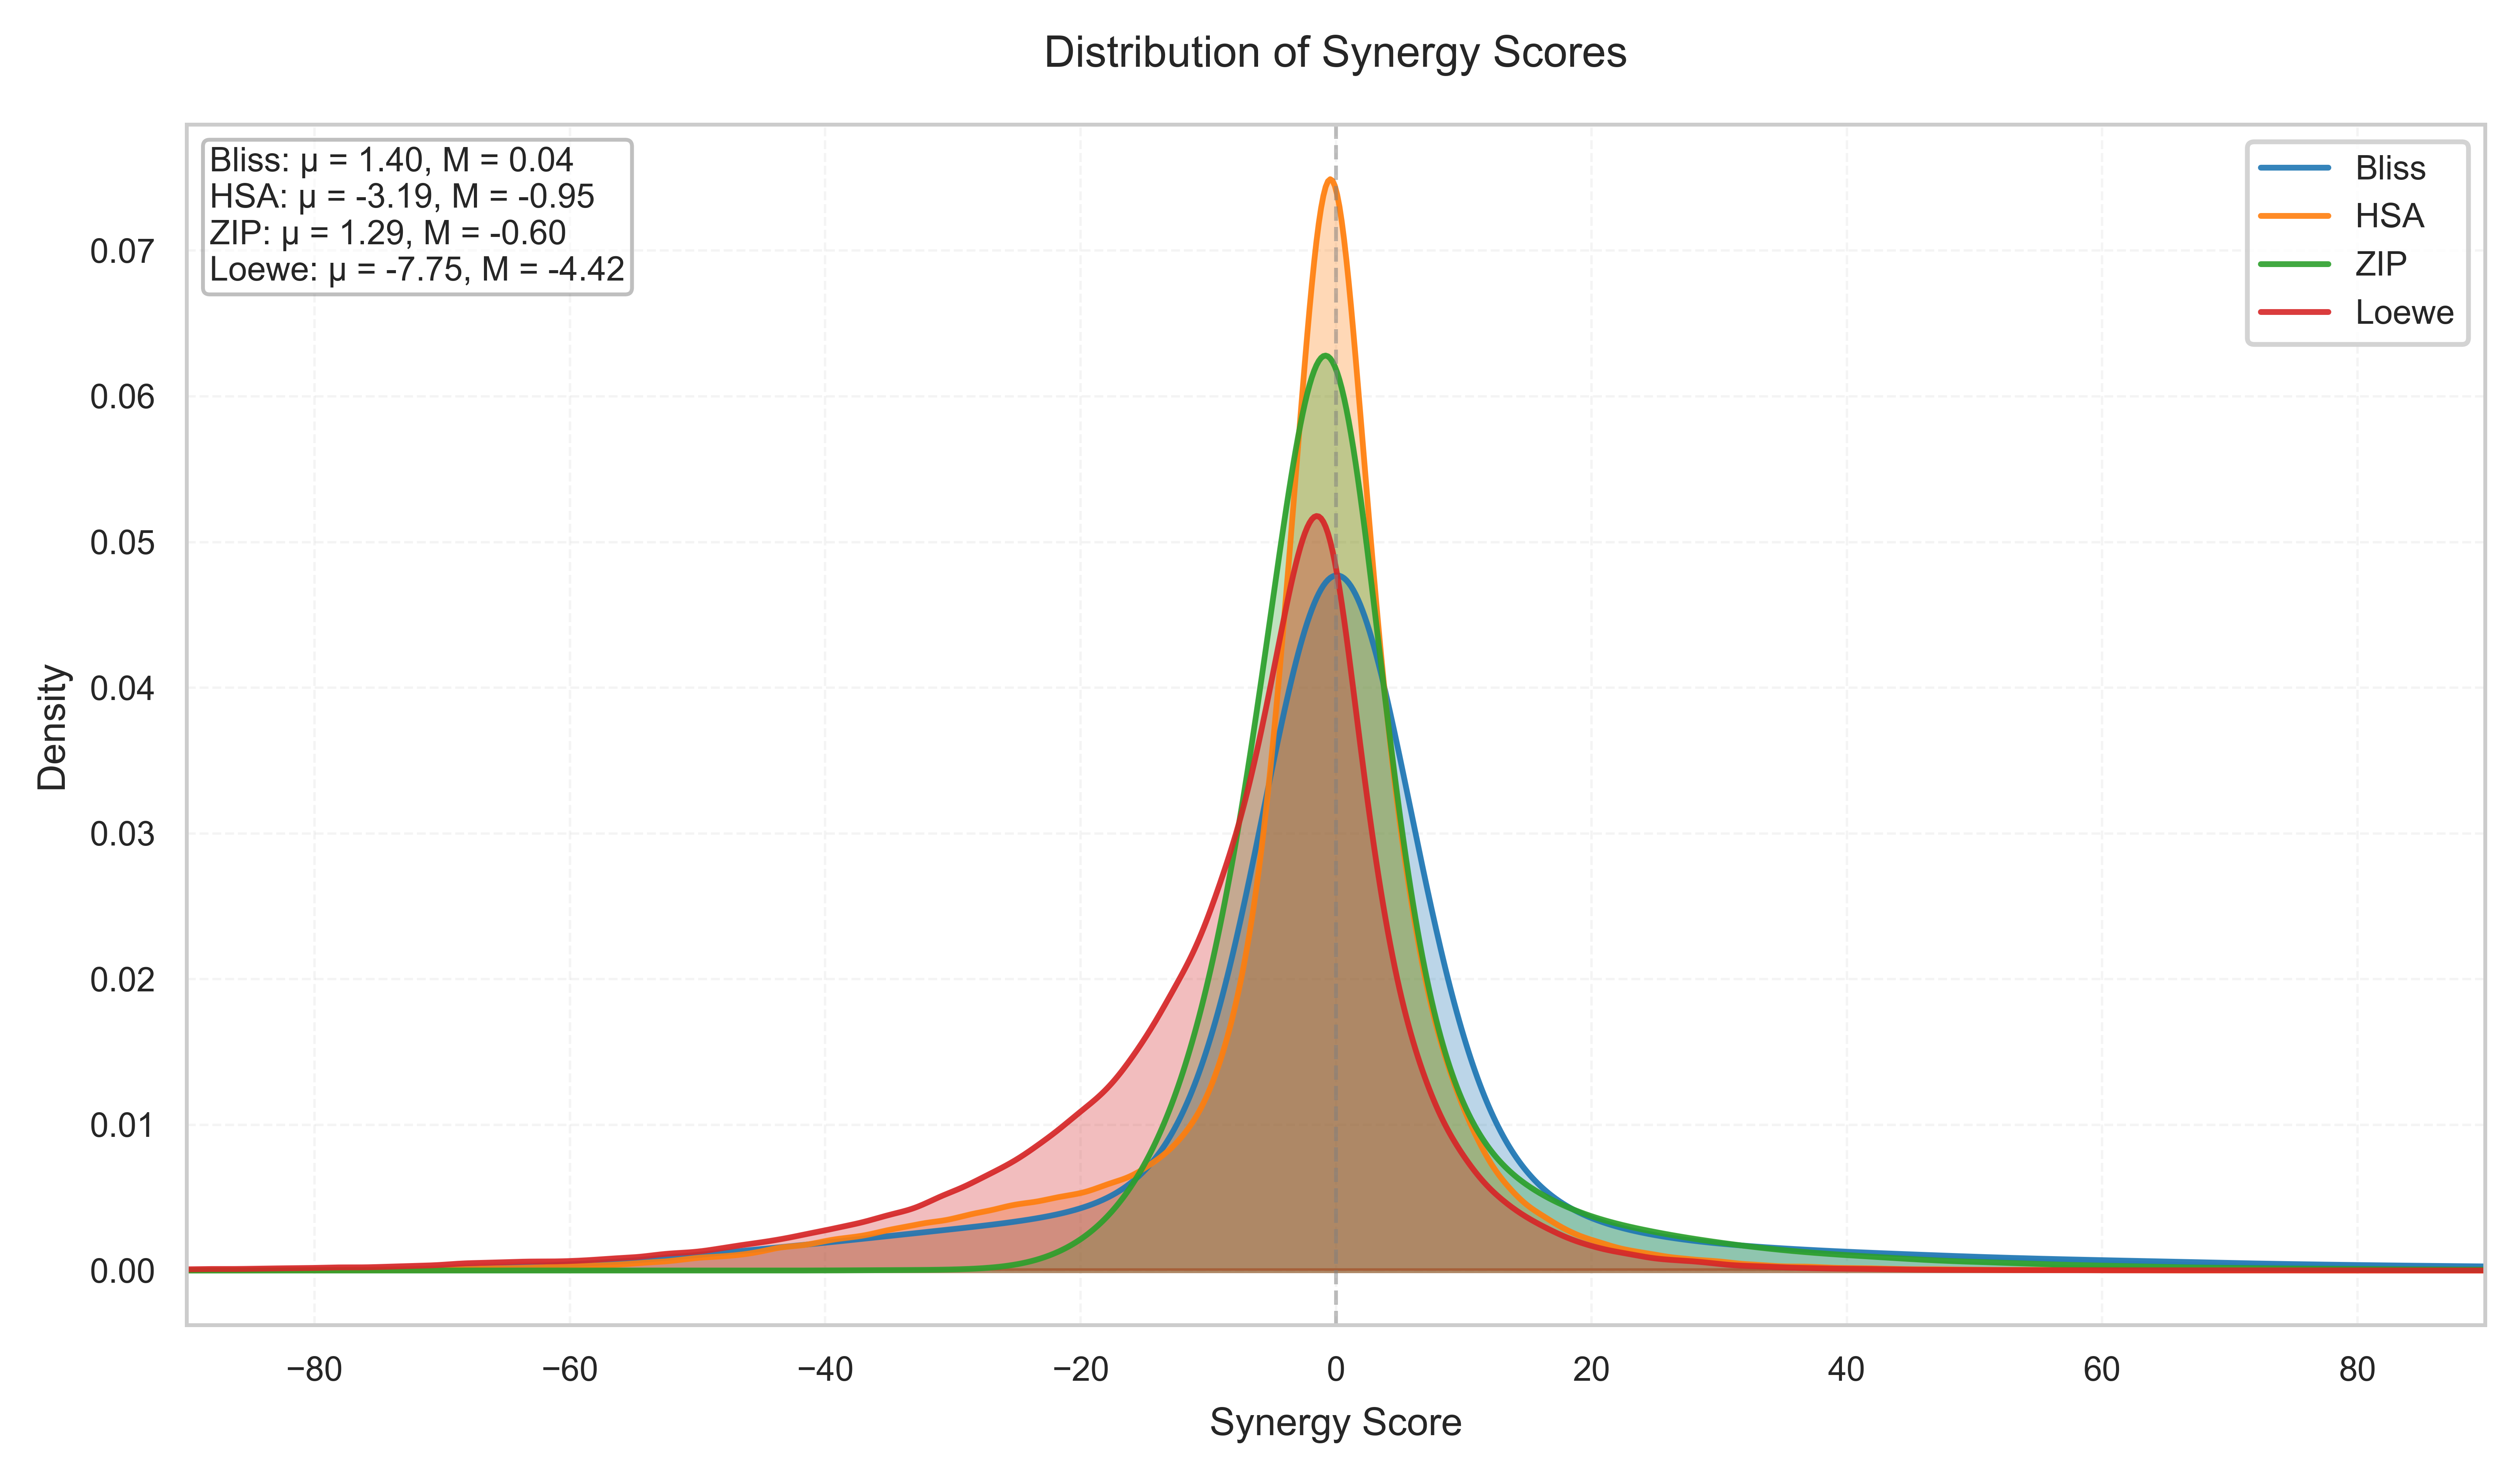

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SCI_STYLE = {
    'font.family': 'Arial',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 900,
    'savefig.format': 'tiff',
    'axes.linewidth': 0.8, 
    'grid.linewidth': 0.5, 
}

plt.rcParams.update(SCI_STYLE)

df = pd.read_csv("../dataset_1/database/drug_comb/drugcomb_cleaned_with_mean_int.csv")
df.dropna(subset=['drug_row', 'drug_col', 'cell_line_name'], inplace=True)

synergy_columns = ['synergy_bliss', 'synergy_hsa', 'synergy_zip', 'synergy_loewe']
synergy_data = df[synergy_columns].copy()

custom_xlim = (-90, 90)

overall_min, overall_max = custom_xlim

plt.figure(figsize=(7.5, 4.5))  
ax = plt.gca()

sns.set_style("whitegrid") 
ax.set_facecolor('white') 

line_colors = {
    'synergy_bliss': '#1f77b4',  
    'synergy_hsa': '#ff7f0e',    
    'synergy_zip': '#2ca02c',    
    'synergy_loewe': '#d62728'   
}

synergy_names = {
    'synergy_bliss': 'Bliss',
    'synergy_hsa': 'HSA',
    'synergy_zip': 'ZIP',
    'synergy_loewe': 'Loewe'
}

line_widths = {
    'synergy_bliss': 1.2,
    'synergy_hsa': 1.2,
    'synergy_zip': 1.2,
    'synergy_loewe': 1.2
}

for i, col in enumerate(synergy_columns):
    data = synergy_data[col].dropna()

    kde = stats.gaussian_kde(data)
    x = np.linspace(overall_min, overall_max, 1000)
    y = kde(x)

    plt.fill_between(x, 0, y, color=line_colors[col], alpha=0.3)  
 
    label = synergy_names[col]
    plt.plot(x, y, 
             color=line_colors[col], 
             linewidth=line_widths[col], 
             alpha=0.9,  
             label=label,
             linestyle='-')

stats_text = []
for col in synergy_columns:
    data = synergy_data[col].dropna()
    mean, median = data.mean(), data.median()
    label = synergy_names[col]
    stats_text.append(f"{label}: μ = {mean:.2f}, M = {median:.2f}")

plt.annotate("\n".join(stats_text), 
             xy=(0.01, 0.87),  
             xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.5", lw=0.8, alpha=0.5, edgecolor="0.5",),
             fontsize=7,  
             ha='left')

plt.title('Distribution of Synergy Scores', fontsize=9, pad=12) 
plt.xlabel('Synergy Score', fontsize=8, labelpad=4)  
plt.ylabel('Density', fontsize=8, labelpad=4)  

plt.legend(loc='upper right', frameon=True, framealpha=0.85, fontsize=7)  

ax.grid(True, linestyle='--', alpha=0.2)

plt.xlim(overall_min, overall_max)

plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, lw=0.8)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

ax.tick_params(width=0.8, length=3, labelsize=7)  

plt.tight_layout(pad=2)  
plt.savefig('synergy_distribution_sci.tiff', dpi=900, bbox_inches='tight', facecolor='white')
plt.show()

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

df = pd.read_csv("../dataset_1/database/drug_comb/drugcomb_cleaned_with_mean_int.csv")
df.dropna(subset=['drug_row', 'drug_col', 'cell_line_name'], inplace=True)

synergy_columns = ['synergy_bliss', 'synergy_hsa', 'synergy_zip', 'synergy_loewe']

pcc_matrix = pd.DataFrame(
    index=['Bliss', 'HSA', 'ZIP', 'Loewe'],
    columns=['Bliss', 'HSA', 'ZIP', 'Loewe']
)

for i, col1 in enumerate(synergy_columns):
    for j, col2 in enumerate(synergy_columns):
        clean_df = df[[col1, col2]].dropna()

        if len(clean_df) > 10:
            arr1 = clean_df[col1].values.flatten()
            arr2 = clean_df[col2].values.flatten()

            if arr1.ndim != 1 or arr2.ndim != 1:
                print(f"维度错误: col1={col1}, col2={col2}")
                print(f"arr1 shape: {arr1.shape}, arr2 shape: {arr2.shape}")
                continue

            try:
                corr, p_value = pearsonr(arr1, arr2)
                row_name = ['Bliss', 'HSA', 'ZIP', 'Loewe'][i]
                col_name = ['Bliss', 'HSA', 'ZIP', 'Loewe'][j]

                pcc_matrix.loc[row_name, col_name] = round(corr, 4)
            except Exception as e:
                print(f"计算相关系数时出错: {e}")
                print(f"col1={col1}, col2={col2}")
                print(f"arr1 shape: {arr1.shape}, arr2 shape: {arr2.shape}")
                pcc_matrix.loc[row_name, col_name] = np.nan
        else:
            row_name = ['Bliss', 'HSA', 'ZIP', 'Loewe'][i]
            col_name = ['Bliss', 'HSA', 'ZIP', 'Loewe'][j]
            pcc_matrix.loc[row_name, col_name] = np.nan

for i in range(len(pcc_matrix)):
    pcc_matrix.iloc[i, i] = 1.0000

pcc_matrix.to_csv('synergy_metrics_correlation.csv', index=True)

print(pcc_matrix)

皮尔逊相关系数矩阵已保存为 'synergy_metrics_correlation.csv'
        Bliss     HSA     ZIP   Loewe
Bliss     1.0   0.218  0.9839  0.3062
HSA     0.218     1.0  0.1253  0.2988
ZIP    0.9839  0.1253     1.0   0.301
Loewe  0.3062  0.2988   0.301     1.0
